In [1023]:
import pandas as pd
import numpy as np 
import seaborn as sns 

In [1024]:
data = pd.read_csv("smartcart_customers.csv")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [1025]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [1026]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Handle Missing Values

In [1027]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
data[["Income"]] = imputer.fit_transform(data[["Income"]])

In [1028]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# 2. Feature Engineering  

In [1029]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [1030]:
#AGE
data["Age"] = 2026-data["Year_Birth"]

In [1031]:
# Customer joining Date!
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"],dayfirst=True)
reference_date = data["Dt_Customer"].max()
data["Customer_Tenure_Days"] = (reference_date-data["Dt_Customer"]).dt.days

In [1032]:
# Spending:
data["total_spend"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]

In [1033]:
# kids:
data["Total_kids"] = data["Kidhome"] + data["Teenhome"]

In [1034]:
# education:
data["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [1035]:
# form Catgoires :
data ["Education"] = data["Education"].replace({
"Basic":"undergraduate",
"2n Cycle":"undergraduate",
"Graduation":"Graduate",
"Master": "PostGraduation",
"PhD":"PostGraduation"
})

In [1036]:
data["Education"].value_counts()

Education
Graduate          1127
PostGraduation     856
undergraduate      257
Name: count, dtype: int64

In [1037]:
data["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [1038]:
data["Marital_Status"] = data["Marital_Status"].replace({
    "Married":"Married",
    "Together":"Married",
    "Single":"Single",
    "Alone": "Single",
    "Absurd":"Single",
    "YOLO":"Single",
    "Widow":"Single",
    "Divorced":"Single"
})

In [1039]:
data["Marital_Status"].value_counts()

Marital_Status
Married    1444
Single      796
Name: count, dtype: int64

In [1040]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'total_spend',
       'Total_kids'],
      dtype='object')

In [1041]:
cols = ['ID', 'Year_Birth','Kidhome',
       'Teenhome', 'Dt_Customer', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cleaned_data = data.drop(cols,axis=1)

In [1042]:
cleaned_data.head() 

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spend,Total_kids
0,Graduate,Single,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0
1,Graduate,Single,46344.0,38,2,1,1,2,5,0,0,72,113,27,2
2,Graduate,Married,71613.0,26,1,8,2,10,4,0,0,61,312,776,0
3,Graduate,Married,26646.0,26,2,2,0,4,6,0,0,42,139,53,1
4,PostGraduation,Married,58293.0,94,5,5,3,6,5,0,0,45,161,422,1


# Outliers

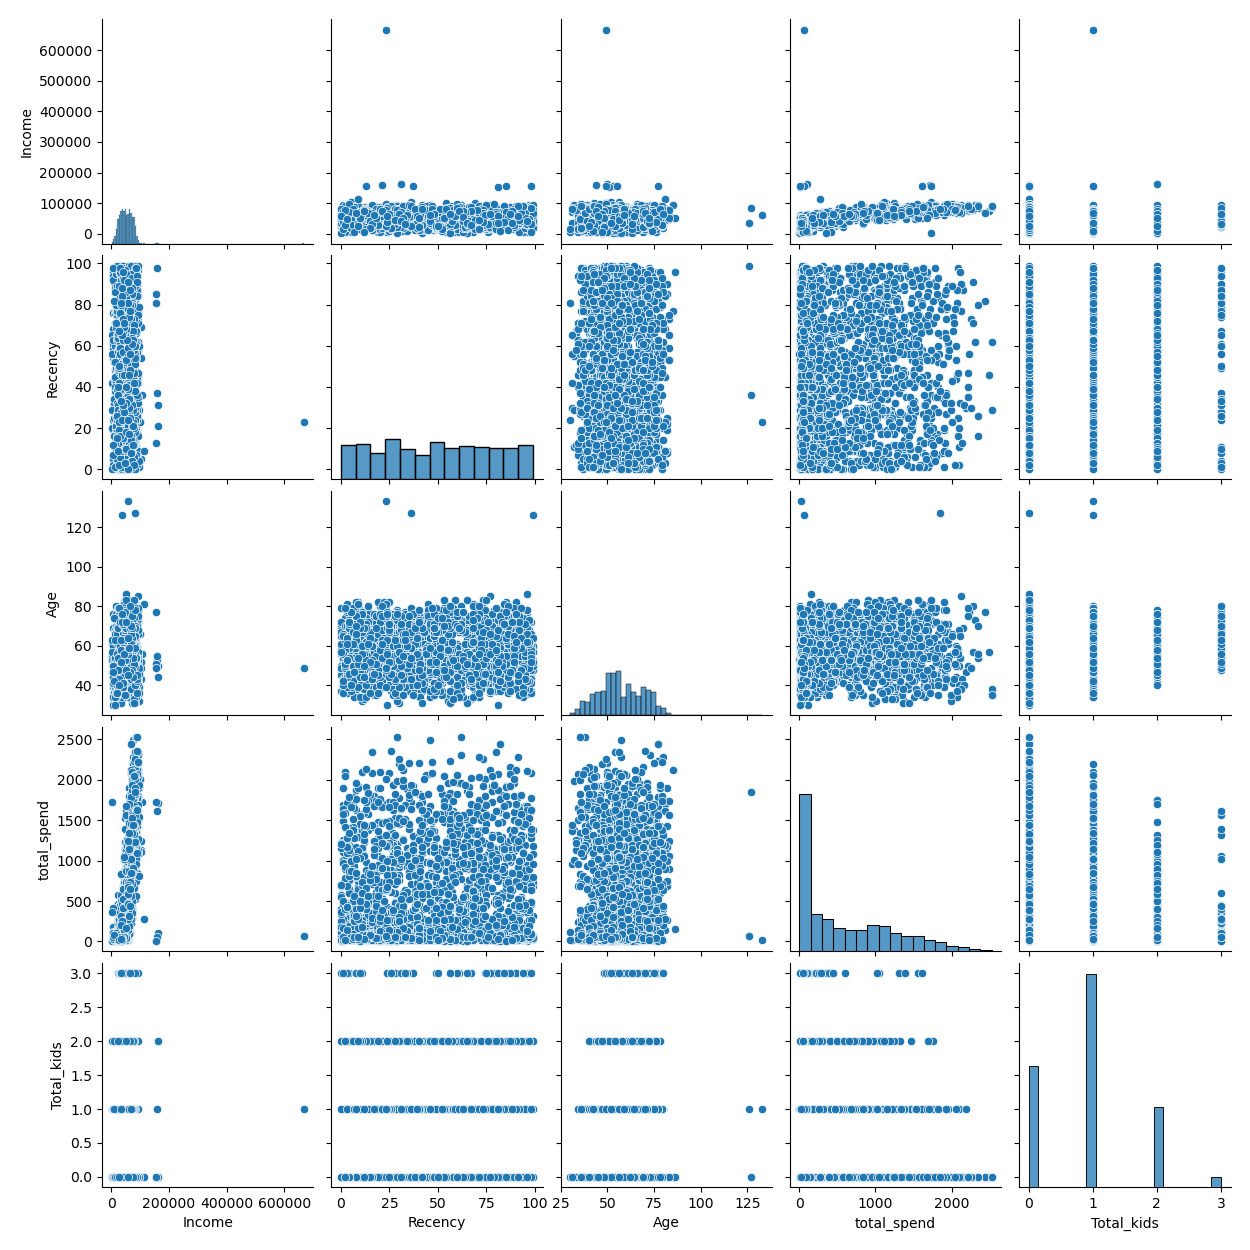

In [1043]:
num_cols = ["Income","Recency","Age","total_spend","Total_kids"]
# plots:
sns.pairplot(cleaned_data[num_cols])

In [1044]:
# remove outliers:
print("data size with outliers:",len(data))
cleaned_data = cleaned_data[(cleaned_data["Age"]<90)]
cleaned_data = cleaned_data[(cleaned_data["Income"]<60_0000)]

data size with outliers: 2240


In [1045]:
print("data size without outliers:",len(cleaned_data))

data size without outliers: 2236


# Heatmap:

In [1046]:
corr = cleaned_data.corr(numeric_only=True)

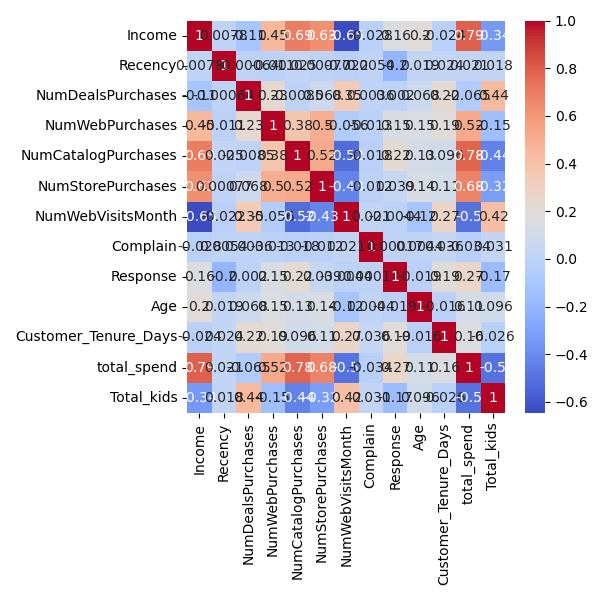

In [1047]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(
    corr,
    annot= True,
    cmap="coolwarm"
)
plt.tight_layout()
plt.show();

# Encoding:

In [1048]:
cleaned_data.shape

(2236, 15)

In [1049]:
cleaned_data.tail()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spend,Total_kids
2235,Graduate,Married,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1
2236,PostGraduation,Married,64014.0,56,7,8,2,5,7,0,0,80,19,444,3
2237,Graduate,Single,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0
2238,PostGraduation,Married,69245.0,8,2,6,5,10,3,0,0,70,156,843,1
2239,PostGraduation,Married,52869.0,40,3,3,1,4,7,0,1,72,622,172,2


In [1050]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = ['Education','Marital_Status']
enc_cols = ohe.fit_transform(cleaned_data[cat_cols])


In [1051]:
new_df =pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=cleaned_data.index)

In [1052]:
new_df.head()

,Education_Graduate,Education_PostGraduation,Education_undergraduate,Marital_Status_Married,Marital_Status_Single
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0


In [1053]:
final_df = pd.concat(
    [cleaned_data.drop(columns=cat_cols), new_df],
    axis=1
)

In [1054]:
final_df.tail()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spend,Total_kids,Education_Graduate,Education_PostGraduation,Education_undergraduate,Marital_Status_Married,Marital_Status_Single
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,1.0,0.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,1.0,0.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,0.0,1.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,1.0,0.0
2239,52869.0,40,3,3,1,4,7,0,1,72,622,172,2,0.0,1.0,0.0,1.0,0.0


In [1055]:
final_df.isnull().sum()

Income                      0
Recency                     0
NumDealsPurchases           0
NumWebPurchases             0
NumCatalogPurchases         0
NumStorePurchases           0
NumWebVisitsMonth           0
Complain                    0
Response                    0
Age                         0
Customer_Tenure_Days        0
total_spend                 0
Total_kids                  0
Education_Graduate          0
Education_PostGraduation    0
Education_undergraduate     0
Marital_Status_Married      0
Marital_Status_Single       0
dtype: int64

# SCALE Data

In [1056]:
X = final_df

In [1057]:
from sklearn.preprocessing import StandardScaler
model = StandardScaler()
scaled_X = model.fit_transform(X)

In [1058]:
scaled_X

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
         0.74204052, -0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
         0.74204052, -0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
         0.74204052, -0.74204052]], shape=(2236, 18))

#  Visualized Data

In [1059]:
sns.scatterplot(x=scaled_X[:,0],y=scaled_X[:,2]) 

<Axes: >

# PCA 

In [1060]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(scaled_X)

In [1061]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1]) 

<Axes: >

In [1062]:
print("PCA:",pca.explained_variance_ratio_)

PCA: [0.23163158 0.11385454 0.10405815]


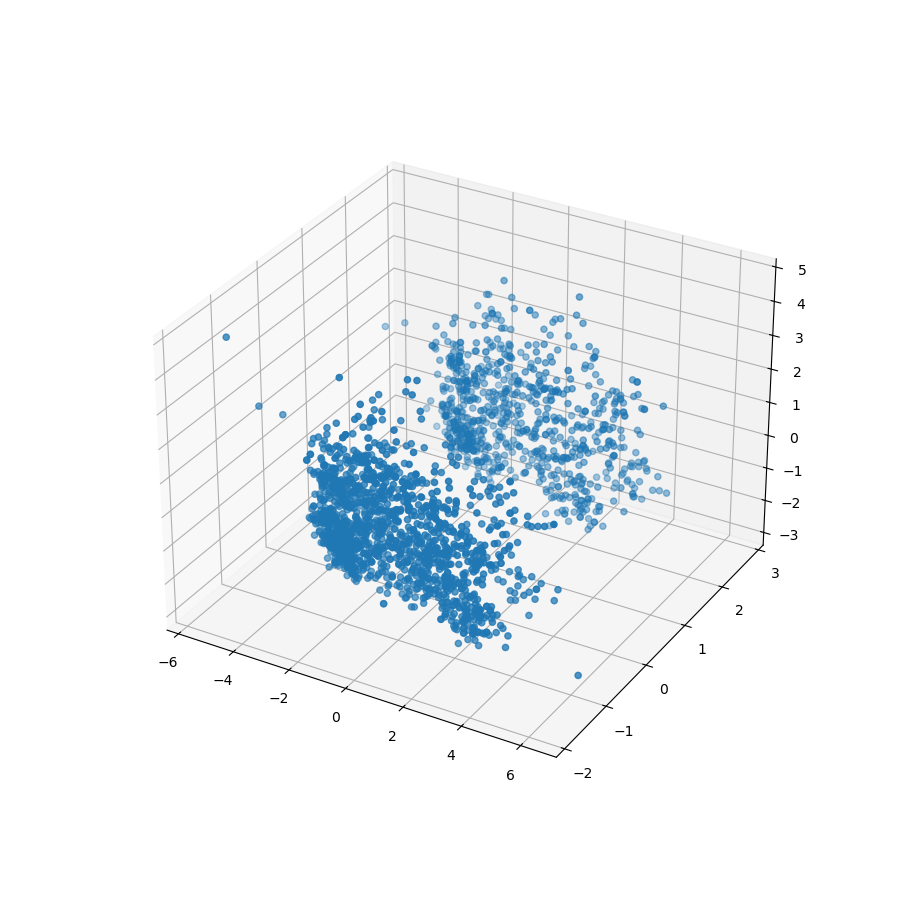

In [1063]:
%matplotlib widget

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

plt.show();

# ELBOW METHODS

In [1064]:
# Analyze:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
model = KMeans()
wcss = []
for k in range(2,10):
    model = KMeans(n_clusters=k)
    model.fit_predict(X_pca)
    labels = model.fit_predict(X_pca)
    score = model.inertia_
    wcss.append(score)

c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [1065]:
from kneed import KneeLocator
knee = KneeLocator(range(2,10),wcss,curve="convex",direction="decreasing")

In [1066]:
optimal_k = knee.elbow

In [1067]:
print("best K:",optimal_k)

best K: 5


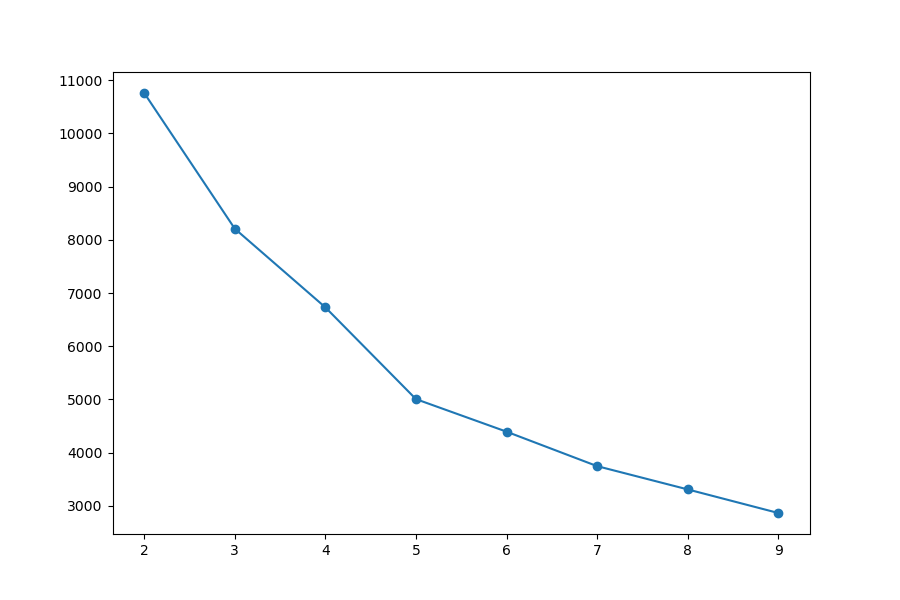

In [1068]:
# plot:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(9,6))
plt.plot(range(2,10) ,wcss, marker= "o")
plt.show();

In [1069]:
from sklearn.metrics import silhouette_score
ss = []
for k in range(2,10):
     model = KMeans(n_clusters=k, random_state=42)
     labels = model.fit_predict(X_pca)
     ss.append(silhouette_score(X_pca, labels))


c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

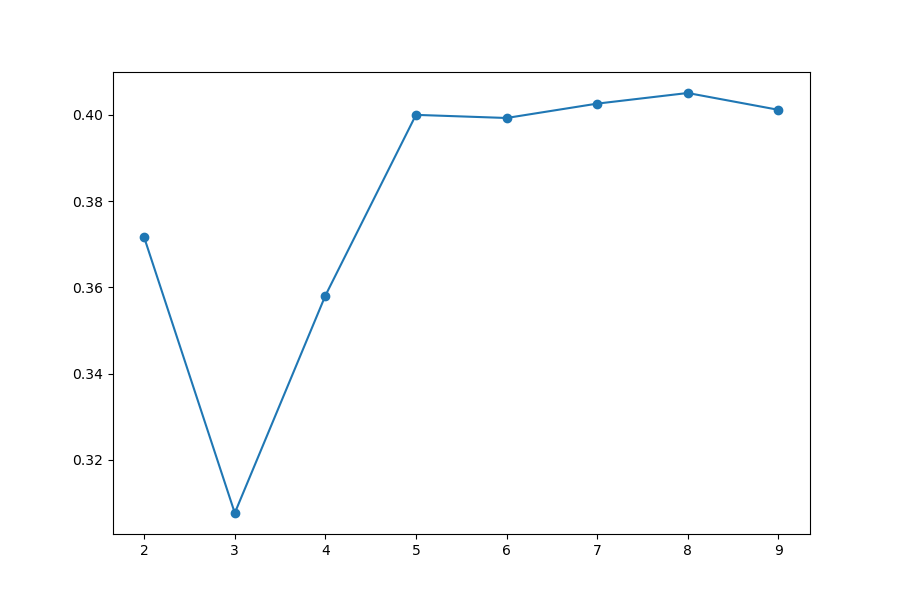

In [1070]:
# plot:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(9,6))
plt.plot(range(2,10) ,ss, marker= "o")
plt.show();

# Combined PLOT:

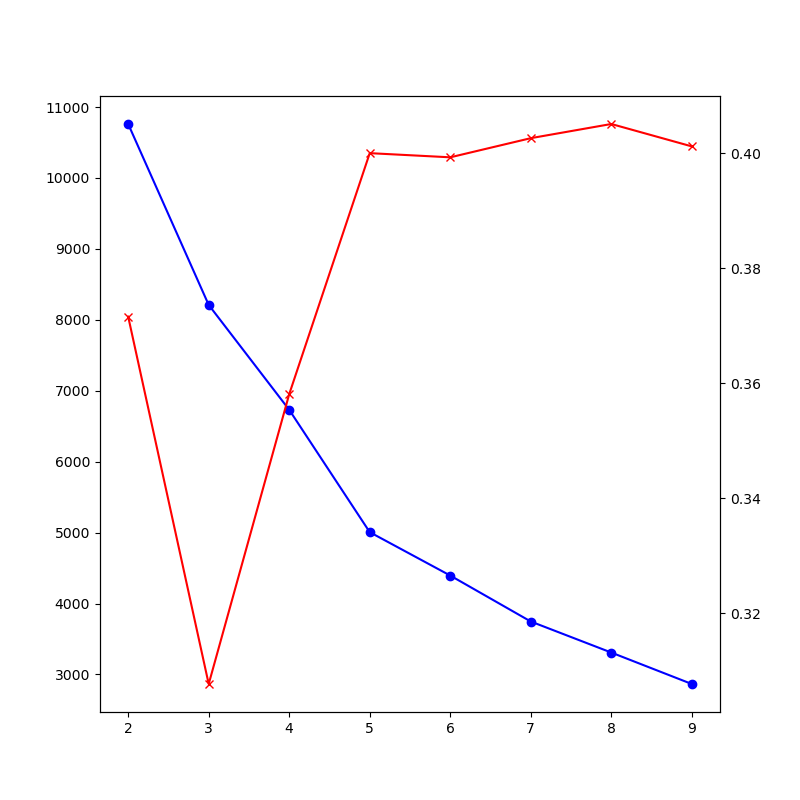

In [1071]:
import matplotlib.pyplot as plt

K_range = range(2, 10)

fig, ax1 = plt.subplots(figsize=(8, 8))
ax1.plot(K_range, wcss[:len(K_range)], marker="o", color="blue")

ax2= ax1.twinx()
ax2.plot(K_range,ss[:len(K_range)],marker="x",color="red",linestyle="-")
plt.show()

In [1072]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4,random_state=42)
wcss = []
for k in range(2,10):
    model = KMeans(n_clusters=k)
    model.fit_predict(scaled_X)
    labels = model.fit_predict(scaled_X)
    score = model.inertia_
    wcss.append(score)

c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\SAHIL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

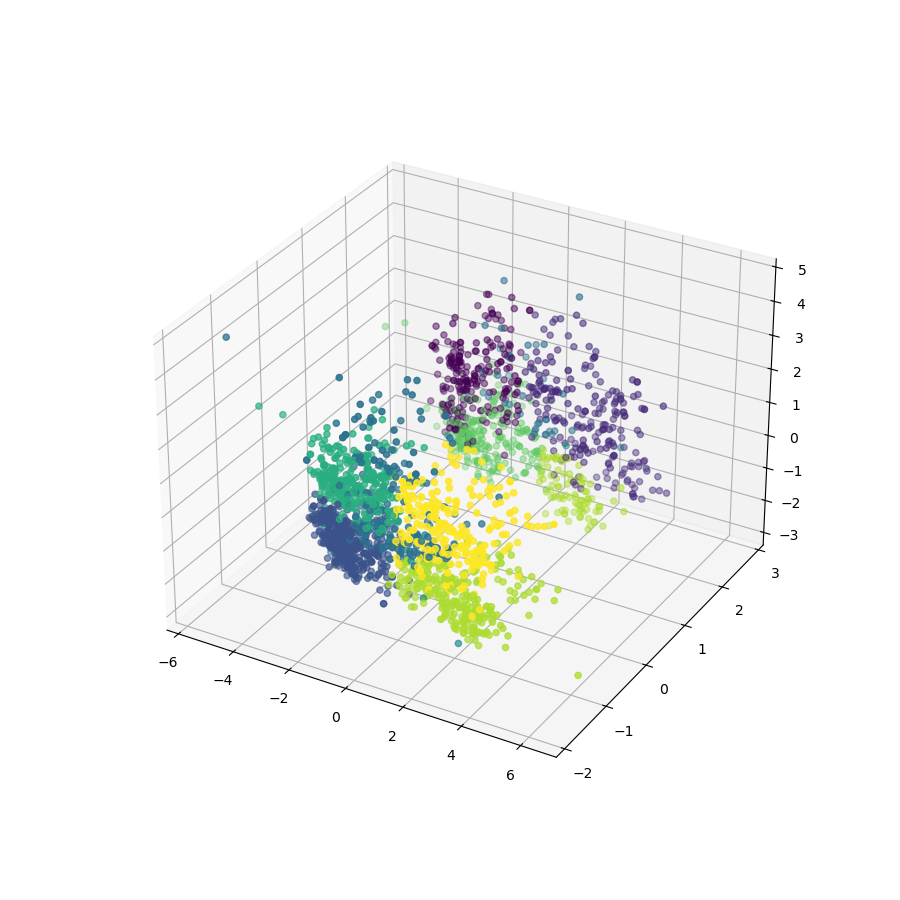

In [1073]:
%matplotlib widget

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],c=labels)

plt.show();

In [1074]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=4,linkage="ward")
agg_labels = model.fit_predict(X_pca)
   

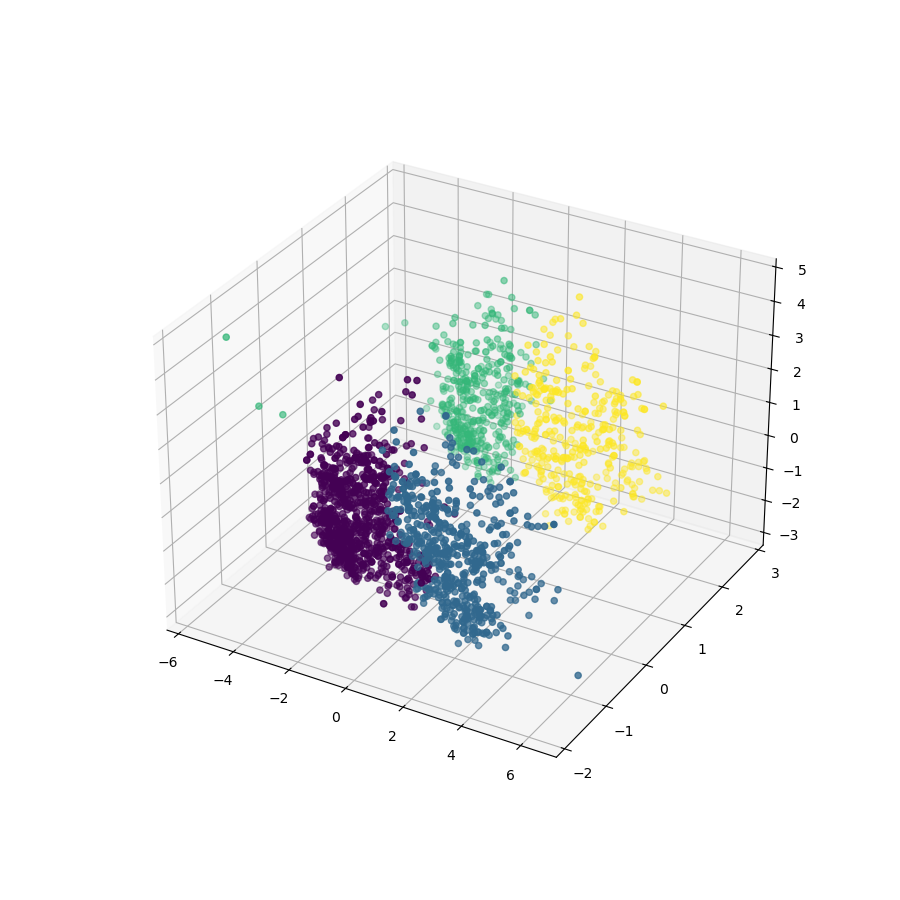

In [1075]:
%matplotlib widget

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],c=agg_labels)

plt.show();

# Charaterization of Clusters 

In [1076]:
cleaned_data["labels"] = agg_labels

In [1077]:
cleaned_data.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spend,Total_kids,labels
0,Graduate,Single,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,3
1,Graduate,Single,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,2
2,Graduate,Married,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1
3,Graduate,Married,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0
4,PostGraduation,Married,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0


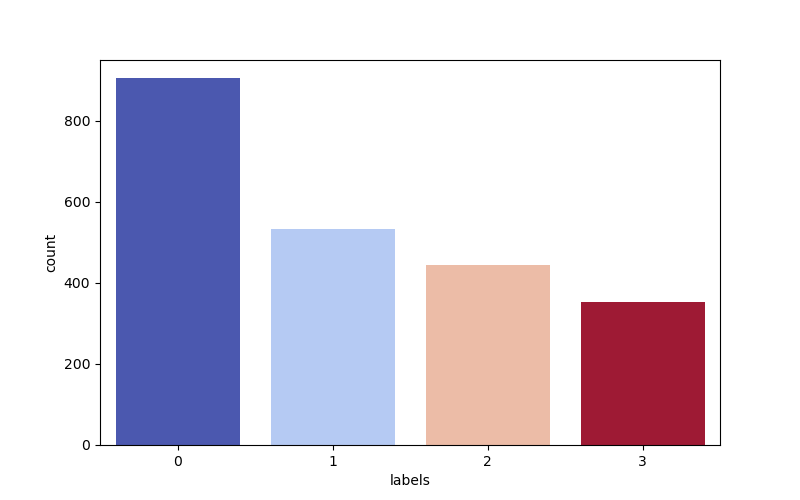

In [1089]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

Pal = ["blue", "red", "green", "yellow"]

sns.countplot(
    x="labels",
    data=cleaned_data,
    hue="labels",
    palette="coolwarm",
    legend=False
)

plt.show()

In [1080]:
cleaned_data.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spend,Total_kids,labels
0,Graduate,Single,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,3
1,Graduate,Single,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,2
2,Graduate,Married,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1
3,Graduate,Married,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0
4,PostGraduation,Married,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0


<Axes: xlabel='total_spend', ylabel='Income'>

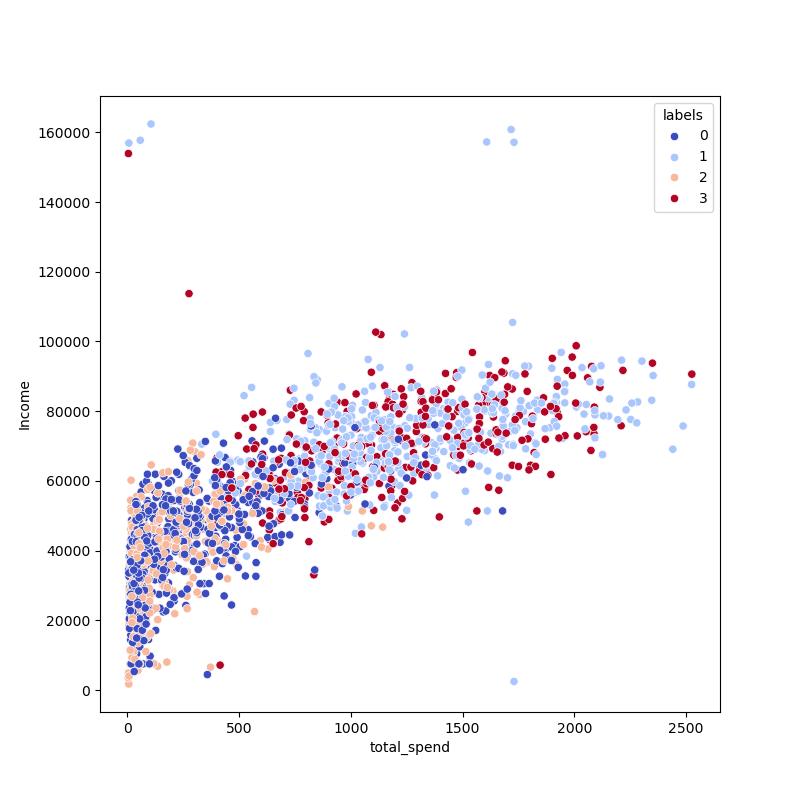

In [1091]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
sns.scatterplot(x=cleaned_data["total_spend"],y = cleaned_data["Income"],hue = cleaned_data["labels"],palette="coolwarm")

In [1104]:
# cluter summary :
cluster_summ = new_df.groupby("labels").mean()

KeyError: 'labels'